# Stage 2 — Plate-character recognition (LPRNet, 7-head CNN, PaddleOCR)

This notebook trains and evaluates three plate-character recognisers on the same frozen test set of CCPD rectified crops:

1. **LPRNet** — small (~0.65 M params) fully-convolutional recogniser with multi-scale feature aggregation, trained with CTC loss. From Zherzdev & Gruzdev, Intel 2018.
2. **7-head CNN** — position-classification model with 7 independent softmax heads, one per plate position. Trained with cross-entropy.
3. **PaddleOCR (PP-OCRv5)** — general-purpose Chinese OCR model used **zero-shot** as the baseline. No training by us.

**Data convention.** All three consume the same rectified plate crops cached at `crnn_plate/labels.csv` and `crnn_plate/crops/`. Build the cache first if it doesn't exist.

**Methodology.** LPRNet: 4-fold stratified CV on the pool, then final retrain on the full pool evaluated on the frozen test set. 7-head CNN: single training run (the architecture is small and stable enough that CV adds noise), frozen-test eval. PaddleOCR: direct evaluation on the frozen test set, no training.

## 1. Imports, configuration, character vocabulary

In [1]:
import os, re, math, random, json, pickle, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(0); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

WORK_ROOT   = Path("crnn_plate")
LABELS_CSV  = WORK_ROOT / "labels.csv"
OUT_DIR     = Path("recognition_results"); OUT_DIR.mkdir(exist_ok=True)
N_FOLDS     = 4
BATCH_SIZE  = 128

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("       ", torch.cuda.get_device_name(0))
assert LABELS_CSV.exists(), (
    f"Cache not found at {LABELS_CSV}. Run the dataset-prep notebook first.")
print(f"using cache: {LABELS_CSV}")

device: cpu
using cache: crnn_plate\labels.csv


## 2. Character vocabulary

In [2]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']

REAL_PROVINCES = [p for p in PROVINCES if p != 'O']     # 33
REAL_LETTERS   = [a for a in ALPHABETS if a != 'O']     # 24
REAL_DIGITS    = [d for d in ADS if d.isdigit()]        # 10

VOCAB    = ['<blank>'] + REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS
CHAR2IDX = {c: i for i, c in enumerate(VOCAB)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
N_CLASSES = len(VOCAB); BLANK_IDX = 0

HEAD_CLASSES = [
    REAL_PROVINCES,
    REAL_LETTERS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
]
HEAD_CHAR2IDX = [{c: i for i, c in enumerate(h)} for h in HEAD_CLASSES]
HEAD_IDX2CHAR = [{i: c for c, i in m.items()} for m in HEAD_CHAR2IDX]
HEAD_SIZES    = [len(h) for h in HEAD_CLASSES]

def encode_ctc(plate):
    return [CHAR2IDX[c] for c in plate]
def encode_7head(plate):
    return [HEAD_CHAR2IDX[i][plate[i]] for i in range(7)]

print(f"CTC vocabulary: {N_CLASSES} classes (incl. blank)")
print(f"7-head sizes:   {HEAD_SIZES}")

CTC vocabulary: 68 classes (incl. blank)
7-head sizes:   [33, 24, 34, 34, 34, 34, 34]


## 3. Load the cache and split

In [3]:
df = pd.read_csv(LABELS_CSV)
print(f"Total cached crops: {len(df):,}\n")
print("By split:")
print(df.groupby(["split","subset"]).size().unstack(fill_value=0))

pool_df = df[df["split"] == "pool"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)
print(f"\npool: {len(pool_df)}  | test: {len(test_df)}")

Total cached crops: 7,750

By split:
subset  CCPD2019  ccpd_base  ccpd_blur  ccpd_challenge  ccpd_db  ccpd_fn  \
split                                                                      
pool        2704       1609        317             529      241      320   
test         478        284         56              93       43       56   

subset  ccpd_rotate  ccpd_tilt  ccpd_weather  
split                                         
pool            241        386           241  
test             42         68            42  

pool: 6588  | test: 1162


## 4. PyTorch dataset (shared by both PyTorch models)

In [4]:
class PlateCropDataset(Dataset):
    def __init__(self, df, crop_h, crop_w, augment=False):
        self.df = df.reset_index(drop=True)
        self.crop_h, self.crop_w = crop_h, crop_w
        self.augment = augment
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.imread(r["path"])
        if img is None:
            img = np.zeros((self.crop_h, self.crop_w, 3), dtype=np.uint8)
        if img.shape[:2] != (self.crop_h, self.crop_w):
            img = cv2.resize(img, (self.crop_w, self.crop_h))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.augment:
            if random.random() < 0.5:
                img = np.clip(img.astype(np.float32) * random.uniform(0.85, 1.15), 0, 255).astype(np.uint8)
            if random.random() < 0.5:
                tx, ty = random.randint(-2, 2), random.randint(-1, 1)
                M = np.float32([[1,0,tx],[0,1,ty]])
                img = cv2.warpAffine(img, M, (self.crop_w, self.crop_h), borderValue=(127,127,127))
        x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
        x = torch.from_numpy(x).permute(2, 0, 1)
        plate = r["plate"]
        ctc_idxs = torch.tensor(encode_ctc(plate), dtype=torch.long)
        head_lbls = torch.tensor(encode_7head(plate), dtype=torch.long)
        return x, ctc_idxs, len(ctc_idxs), head_lbls, plate

def ctc_collate(batch):
    xs, ctc_idxs, lens, _, plates = zip(*batch)
    return (torch.stack(xs, 0),
            torch.cat(ctc_idxs, 0),
            torch.tensor(lens, dtype=torch.long),
            list(plates))

def head_collate(batch):
    xs, _, _, head_lbls, plates = zip(*batch)
    return (torch.stack(xs, 0),
            torch.stack(head_lbls, 0),
            list(plates))

## 5. Evaluation helpers (shared)

In [5]:
def greedy_ctc_decode(logits_TBV):
    idx = logits_TBV.argmax(dim=2).cpu().numpy()
    T, B = idx.shape
    out = []
    for b in range(B):
        seq = []; prev = -1
        for t in range(T):
            c = int(idx[t, b])
            if c != prev and c != BLANK_IDX:
                seq.append(IDX2CHAR[c])
            prev = c
        out.append(''.join(seq))
    return out

def edit_distance(a: str, b: str) -> int:
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    dp = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        prev, dp[0] = dp[0], i
        for j, cb in enumerate(b, 1):
            cur = dp[j]
            dp[j] = prev if ca == cb else 1 + min(prev, dp[j], dp[j-1])
            prev = cur
    return dp[-1]

POS_LABELS = ["pos1 (province)", "pos2 (letter)",
              "pos3", "pos4", "pos5", "pos6", "pos7"]

def evaluate_predictions(preds, truths):
    n = len(preds); assert n == len(truths)
    full_correct = 0; ed_sum = 0
    pos_correct = np.zeros(7, dtype=np.int64)
    pos_total   = np.zeros(7, dtype=np.int64)
    for p, t in zip(preds, truths):
        ed_sum += edit_distance(p, t)
        if p == t: full_correct += 1
        if len(t) == 7:
            for i in range(7):
                pos_total[i] += 1
                if i < len(p) and p[i] == t[i]:
                    pos_correct[i] += 1
    return {
        "n": n,
        "full_plate_acc": full_correct / max(n, 1),
        "mean_edit_dist": ed_sum / max(n, 1),
        "per_position_acc": (pos_correct / np.maximum(pos_total, 1)).tolist(),
    }

## 6. Recogniser A — LPRNet

In [6]:
LPRNET_CROP_H, LPRNET_CROP_W = 24, 94

class small_basic_block(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        ch_mid = ch_out // 4
        self.block = nn.Sequential(
            nn.Conv2d(ch_in,  ch_mid, kernel_size=1), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(3,1), padding=(1,0)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(1,3), padding=(0,1)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_out, kernel_size=1),
        )
    def forward(self, x): return self.block(x)

class LPRNet(nn.Module):
    def __init__(self, class_num=N_CLASSES, dropout_rate=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),
            small_basic_block(64, 128), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            small_basic_block(128, 256), nn.BatchNorm2d(256), nn.ReLU(),
            small_basic_block(256, 256), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, 256, kernel_size=(1,4), stride=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, class_num, kernel_size=(13,1)),
            nn.BatchNorm2d(class_num), nn.ReLU(),
        )
        self.container = nn.Conv2d(64+128+256+class_num, class_num, kernel_size=1)
        with torch.no_grad():
            self.container.bias.zero_()
            self.container.bias[BLANK_IDX] = -2.0
    def forward(self, x):
        keep = {2, 6, 13, 22}
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in keep: feats.append(x)
        H_out, W_out = feats[-1].shape[2], feats[-1].shape[3]
        normed = []
        for f in feats:
            f_n = f.div(f.pow(2).mean().clamp(min=1e-8))
            if f.shape[2:] != (H_out, W_out):
                f_n = F.adaptive_avg_pool2d(f_n, (H_out, W_out))
            normed.append(f_n)
        cat = torch.cat(normed, dim=1)
        logits = self.container(cat).mean(dim=2)
        return logits.permute(2, 0, 1).contiguous()

_m = LPRNet(N_CLASSES)
with torch.no_grad():
    _y = _m(torch.randn(2, 3, LPRNET_CROP_H, LPRNET_CROP_W))
print(f"LPRNet output: {_y.shape} | params: {sum(p.numel() for p in _m.parameters())/1e6:.2f} M")
del _m

LPRNet output: torch.Size([18, 2, 68]) | params: 0.65 M


### 6.1 LPRNet — train-one-fold helper

In [7]:
def train_lprnet_one_fold(train_df, val_df, epochs=30, batch_size=BATCH_SIZE,
                          lr=1e-3, weight_decay=1e-4, patience=20, verbose=True):
    train_loader = DataLoader(PlateCropDataset(train_df, LPRNET_CROP_H, LPRNET_CROP_W, augment=True),
                              batch_size=batch_size, shuffle=True, num_workers=0,
                              collate_fn=ctc_collate, pin_memory=(DEVICE=="cuda"))
    val_loader   = DataLoader(PlateCropDataset(val_df, LPRNET_CROP_H, LPRNET_CROP_W),
                              batch_size=batch_size, shuffle=False, num_workers=0,
                              collate_fn=ctc_collate)
    model = LPRNet(N_CLASSES).to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    ctc   = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
    best_edit = float("inf"); best_state = None; stale = 0; history = []
    for ep in range(1, epochs+1):
        model.train(); loss_sum = 0.0; n = 0; t0 = time.time()
        for xb, targets, target_lens, _ in train_loader:
            xb = xb.to(DEVICE); targets = targets.to(DEVICE); target_lens = target_lens.to(DEVICE)
            logits = model(xb)
            log_probs = F.log_softmax(logits, dim=2)
            T_, B, _ = log_probs.shape
            input_lens = torch.full((B,), T_, dtype=torch.long, device=DEVICE)
            loss = ctc(log_probs, targets, input_lens, target_lens)
            optim.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0); optim.step()
            loss_sum += loss.item() * B; n += B
        sched.step()
        model.eval(); val_preds, val_truths = [], []
        with torch.no_grad():
            for xb, _, _, plates in val_loader:
                val_preds.extend(greedy_ctc_decode(model(xb.to(DEVICE))))
                val_truths.extend(plates)
        val = evaluate_predictions(val_preds, val_truths)
        history.append({"epoch": ep, "train_loss": loss_sum/max(n,1),
                        **{k: v for k, v in val.items() if k != "per_position_acc"}})
        if verbose:
            print(f"  ep {ep:3d} | loss {loss_sum/max(n,1):.4f} | val full {val['full_plate_acc']:.4f} "
                  f"| edit {val['mean_edit_dist']:.3f} | {time.time()-t0:.1f}s")
        if val["mean_edit_dist"] < best_edit:
            best_edit = val["mean_edit_dist"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose: print(f"  early stop @ ep {ep} (best edit={best_edit:.3f})")
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

### 6.2 LPRNet — 4-fold stratified cross-validation

In [8]:
def make_stratified_folds(df, n_folds, seed=0):
    rng = random.Random(seed + 7)
    by_subset = {}
    for i, r in df.iterrows():
        by_subset.setdefault(r["subset"], []).append(i)
    fold_of = {}
    for subset, ids in by_subset.items():
        ids = list(ids); rng.shuffle(ids)
        for j, idx in enumerate(ids):
            fold_of[idx] = j % n_folds
    df = df.copy()
    df["fold"] = df.index.map(fold_of)
    return df

pool_with_folds = make_stratified_folds(pool_df, N_FOLDS, seed=0)
print("pool fold sizes:", pool_with_folds["fold"].value_counts().sort_index().to_dict())

pool fold sizes: {0: 1652, 1: 1646, 2: 1645, 3: 1645}


In [9]:
EPOCHS_CV = 30
cv_rows = []
for k in range(N_FOLDS):
    print(f"\n=== LPRNet fold {k} ===")
    tr = pool_with_folds[pool_with_folds["fold"] != k]
    va = pool_with_folds[pool_with_folds["fold"] == k]
    print(f"  train: {len(tr)} | val: {len(va)}")
    model_k, _ = train_lprnet_one_fold(tr, va, epochs=EPOCHS_CV, verbose=True)
    val_loader = DataLoader(PlateCropDataset(va, LPRNET_CROP_H, LPRNET_CROP_W),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                            collate_fn=ctc_collate)
    model_k.eval(); preds, truths = [], []
    with torch.no_grad():
        for xb, _, _, plates in val_loader:
            preds.extend(greedy_ctc_decode(model_k(xb.to(DEVICE))))
            truths.extend(plates)
    m = evaluate_predictions(preds, truths); m["fold"] = k
    cv_rows.append(m)
    del model_k
    if DEVICE == "cuda": torch.cuda.empty_cache()

lprnet_cv_df = pd.DataFrame(cv_rows)
display(lprnet_cv_df[["fold","n","full_plate_acc","mean_edit_dist"]])
print(f"\nLPRNet CV: full-plate {lprnet_cv_df['full_plate_acc'].mean():.4f} ± "
      f"{lprnet_cv_df['full_plate_acc'].std():.4f}")


=== LPRNet fold 0 ===
  train: 4936 | val: 1652


KeyboardInterrupt: 

### 6.3 LPRNet — final retrain on full pool, frozen-test eval

In [10]:
FINAL_EPOCHS = 40
rng = random.Random(123)
final_train_idx, final_val_idx = [], []
for subset, group in pool_df.groupby("subset"):
    idxs = list(group.index); rng.shuffle(idxs)
    nv = max(1, int(0.10 * len(idxs)))
    final_val_idx.extend(idxs[:nv]); final_train_idx.extend(idxs[nv:])
ft_df = pool_df.loc[final_train_idx].reset_index(drop=True)
fv_df = pool_df.loc[final_val_idx].reset_index(drop=True)
print(f"final retrain — train: {len(ft_df)} | val: {len(fv_df)}")

lprnet_final, lprnet_hist = train_lprnet_one_fold(
    ft_df, fv_df, epochs=FINAL_EPOCHS, patience=20, verbose=True)

final retrain — train: 5933 | val: 655


KeyboardInterrupt: 

In [ ]:
test_loader = DataLoader(PlateCropDataset(test_df, LPRNET_CROP_H, LPRNET_CROP_W),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                        collate_fn=ctc_collate)
lprnet_final.eval(); preds, truths = [], []
with torch.no_grad():
    for xb, _, _, plates in test_loader:
        preds.extend(greedy_ctc_decode(lprnet_final(xb.to(DEVICE))))
        truths.extend(plates)
lprnet_test = evaluate_predictions(preds, truths)
lprnet_test_preds = list(zip(truths, preds))

print("="*60); print("LPRNet — FROZEN TEST"); print("="*60)
print(f"Full-plate: {lprnet_test['full_plate_acc']:.4f}  Mean edit: {lprnet_test['mean_edit_dist']:.3f}  n={lprnet_test['n']}")
print("Per-position:")
for lab, acc in zip(POS_LABELS, lprnet_test["per_position_acc"]):
    print(f"  {lab:18s}: {acc:.4f}")

ckpt = OUT_DIR / "lprnet_final.pt"
torch.save({"model_state_dict": lprnet_final.state_dict(),
            "vocab": VOCAB, "crop_size": (LPRNET_CROP_H, LPRNET_CROP_W),
            "test_metrics": lprnet_test}, ckpt)
print(f"\nSaved → {ckpt}")

NameError: name 'lprnet_final' is not defined

## 7. Recogniser B — 7-head CNN

In [ ]:
HEAD7_CROP_H, HEAD7_CROP_W = 48, 168

class SevenHeadCNN(nn.Module):
    def __init__(self, head_sizes=HEAD_SIZES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.heads = nn.ModuleList([nn.Linear(256, k) for k in head_sizes])
    def forward(self, x):
        f = self.backbone(x)
        return [h(f) for h in self.heads]

_m = SevenHeadCNN()
with torch.no_grad():
    _y = _m(torch.randn(2, 3, HEAD7_CROP_H, HEAD7_CROP_W))
print(f"7-head output: {[tuple(t.shape) for t in _y]}")
print(f"params: {sum(p.numel() for p in _m.parameters())/1e6:.2f} M")
del _m

7-head output: [(2, 33), (2, 24), (2, 34), (2, 34), (2, 34), (2, 34), (2, 34)]
params: 0.45 M


### 7.1 7-head CNN — training

In [ ]:
def decode_7head(logits_list):
    B = logits_list[0].shape[0]
    out = []
    for b in range(B):
        s = "".join(HEAD_IDX2CHAR[i][int(logits_list[i][b].argmax())] for i in range(7))
        out.append(s)
    return out

def train_7head(train_df, val_df, epochs=30, batch_size=BATCH_SIZE,
                lr=1e-3, weight_decay=1e-4, patience=10, verbose=True):
    train_loader = DataLoader(PlateCropDataset(train_df, HEAD7_CROP_H, HEAD7_CROP_W, augment=True),
                              batch_size=batch_size, shuffle=True, num_workers=0,
                              collate_fn=head_collate, pin_memory=(DEVICE=="cuda"))
    val_loader = DataLoader(PlateCropDataset(val_df, HEAD7_CROP_H, HEAD7_CROP_W),
                            batch_size=batch_size, shuffle=False, num_workers=0,
                            collate_fn=head_collate)
    model = SevenHeadCNN().to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    best_state = None; stale = 0; history = []
    best_edit = float("inf")

    for ep in range(1, epochs+1):
        model.train(); loss_sum = 0.0; n = 0; t0 = time.time()
        for xb, labels, _ in train_loader:
            xb = xb.to(DEVICE); labels = labels.to(DEVICE)
            logits_list = model(xb)
            loss = sum(F.cross_entropy(logits_list[i], labels[:, i]) for i in range(7))
            optim.zero_grad(set_to_none=True); loss.backward(); optim.step()
            loss_sum += loss.item() * xb.shape[0]; n += xb.shape[0]
        sched.step()
        model.eval(); val_preds, val_truths = [], []
        with torch.no_grad():
            for xb, _, plates in val_loader:
                val_preds.extend(decode_7head(model(xb.to(DEVICE))))
                val_truths.extend(plates)
        val = evaluate_predictions(val_preds, val_truths)
        history.append({"epoch": ep, "train_loss": loss_sum/max(n,1),
                        **{k: v for k, v in val.items() if k != "per_position_acc"}})
        if verbose:
            print(f"  ep {ep:3d} | loss {loss_sum/max(n,1):.4f} | val full {val['full_plate_acc']:.4f} "
                  f"| edit {val['mean_edit_dist']:.3f} | {time.time()-t0:.1f}s")
        if val["mean_edit_dist"] < best_edit:
            best_edit = val["mean_edit_dist"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose: print(f"  early stop @ ep {ep} (best edit={best_edit:.3f})")
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

SEVEN_EPOCHS = 40
print("Training 7-head CNN on the full pool...")
head7_model, head7_hist = train_7head(ft_df, fv_df, epochs=SEVEN_EPOCHS, verbose=True)

Training 7-head CNN on the full pool...
  ep   1 | loss 18.1070 | val full 0.0000 | edit 4.768 | 49.1s
  ep   2 | loss 16.5755 | val full 0.0000 | edit 4.715 | 41.6s
  ep   3 | loss 16.4823 | val full 0.0000 | edit 4.663 | 44.9s
  ep   4 | loss 16.3045 | val full 0.0000 | edit 4.656 | 44.4s
  ep   5 | loss 16.0653 | val full 0.0000 | edit 4.522 | 44.4s
  ep   6 | loss 15.7517 | val full 0.0000 | edit 4.417 | 45.0s
  ep   7 | loss 15.3971 | val full 0.0000 | edit 4.429 | 45.1s
  ep   8 | loss 14.9661 | val full 0.0000 | edit 4.284 | 45.7s
  ep   9 | loss 14.4815 | val full 0.0000 | edit 4.118 | 47.9s
  ep  10 | loss 14.0323 | val full 0.0000 | edit 4.168 | 46.6s
  ep  11 | loss 13.6559 | val full 0.0000 | edit 3.936 | 44.4s
  ep  12 | loss 13.3322 | val full 0.0000 | edit 3.814 | 46.7s
  ep  13 | loss 13.0257 | val full 0.0000 | edit 3.881 | 45.3s
  ep  14 | loss 12.7366 | val full 0.0000 | edit 3.776 | 45.0s
  ep  15 | loss 12.4612 | val full 0.0000 | edit 3.922 | 45.0s


KeyboardInterrupt: 

### 7.2 7-head CNN — frozen-test eval

In [ ]:
test_loader = DataLoader(PlateCropDataset(test_df, HEAD7_CROP_H, HEAD7_CROP_W),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                         collate_fn=head_collate)
head7_model.eval(); preds, truths = [], []
with torch.no_grad():
    for xb, _, plates in test_loader:
        preds.extend(decode_7head(head7_model(xb.to(DEVICE))))
        truths.extend(plates)
head7_test = evaluate_predictions(preds, truths)
head7_test_preds = list(zip(truths, preds))

print("="*60); print("7-head CNN — FROZEN TEST"); print("="*60)
print(f"Full-plate: {head7_test['full_plate_acc']:.4f}  Mean edit: {head7_test['mean_edit_dist']:.3f}  n={head7_test['n']}")
print("Per-position:")
for lab, acc in zip(POS_LABELS, head7_test["per_position_acc"]):
    print(f"  {lab:18s}: {acc:.4f}")

ckpt = OUT_DIR / "head7_final.pt"
torch.save({"model_state_dict": head7_model.state_dict(),
            "head_sizes": HEAD_SIZES, "crop_size": (HEAD7_CROP_H, HEAD7_CROP_W),
            "test_metrics": head7_test}, ckpt)
print(f"\nSaved → {ckpt}")

7-head CNN — FROZEN TEST
Full-plate: 0.0000  Mean edit: 4.685  n=1162
Per-position:
  pos1 (province)   : 0.9243
  pos2 (letter)     : 0.9002
  pos3              : 0.0327
  pos4              : 0.0706
  pos5              : 0.0990
  pos6              : 0.1162
  pos7              : 0.1179

Saved → recognition_results\head7_final.pt


## 8. Recogniser C — PaddleOCR (zero-shot)

> **Venv note**: PaddleOCR requires a separate Python environment (no Paddle wheels for Python 3.14 yet). If `paddleocr` isn't importable, this section skips gracefully — run it from your `paddle-py313` kernel to get the numbers.

In [15]:
try:
    from paddleocr import TextRecognition
    paddle_available = True
    print("✓ paddleocr importable")
except ImportError:
    paddle_available = False
    print("⚠ paddleocr not importable — skipping section 8.")
    print("  Switch to your paddle-py313 kernel and re-run from this cell.")

✓ paddleocr importable


In [16]:
def extract_text_and_score(res):
    if res is None: return "", 0.0
    for txt_key, sc_key in [("rec_text","rec_score"), ("text","score")]:
        if hasattr(res, "json"):
            try:
                d = res.json
                if isinstance(d, dict) and txt_key in d:
                    return str(d[txt_key]), float(d.get(sc_key, 0.0))
            except Exception: pass
        if hasattr(res, "get") and res.get(txt_key) is not None:
            return str(res[txt_key]), float(res.get(sc_key, 0.0))
        if hasattr(res, txt_key):
            return str(getattr(res, txt_key)), float(getattr(res, sc_key, 0.0))
    if isinstance(res, (tuple, list)) and len(res) >= 2:
        try: return str(res[0]), float(res[1])
        except Exception: pass
    return "", 0.0

VALID_PROVS   = set(REAL_PROVINCES)
VALID_LETTERS = set(REAL_LETTERS)
VALID_DIGITS  = set(REAL_DIGITS)
def clean_paddle_prediction(raw):
    if raw is None: return ""
    s = str(raw).strip().upper()
    s = "".join(c for c in s if not c.isspace() and c not in ".,-•·")
    valid = VALID_PROVS | VALID_LETTERS | VALID_DIGITS
    s = "".join(c for c in s if c in valid)
    return s[:7]

In [17]:
if paddle_available:
    MODEL_NAME = "PP-OCRv5_server_rec"
    print(f"Loading {MODEL_NAME}...")
    recognizer = TextRecognition(model_name=MODEL_NAME)
    BATCH = 16
    test_paths  = test_df["path"].tolist()
    test_truths = test_df["plate"].tolist()
    raw_preds, clean_preds = [], []
    t0 = time.time()
    for start in range(0, len(test_paths), BATCH):
        batch = test_paths[start:start+BATCH]
        outs = recognizer.predict(input=batch, batch_size=len(batch))
        for res in outs:
            raw, _ = extract_text_and_score(res)
            raw_preds.append(raw); clean_preds.append(clean_paddle_prediction(raw))
        done = start + len(batch)
        if done % (BATCH * 20) == 0 or done == len(test_paths):
            dt = time.time() - t0
            print(f"  {done}/{len(test_paths)}  ({dt:.0f}s, {done/dt:.1f} img/s)")
    paddle_test = evaluate_predictions(clean_preds, test_truths)
    paddle_test_preds = list(zip(test_truths, clean_preds))
    print("\n" + "="*60); print("PaddleOCR — FROZEN TEST"); print("="*60)
    print(f"Full-plate: {paddle_test['full_plate_acc']:.4f}  Mean edit: {paddle_test['mean_edit_dist']:.3f}  n={paddle_test['n']}")
    print("Per-position:")
    for lab, acc in zip(POS_LABELS, paddle_test["per_position_acc"]):
        print(f"  {lab:18s}: {acc:.4f}")
else:
    paddle_test = None; paddle_test_preds = None
    print("Skipped.")

Loading PP-OCRv5_server_rec...


c:\Users\PC\Desktop\Github\IS_Project\IS_AY2526\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `C:\Users\PC\.paddlex\official_models\PP-OCRv5_server_rec`.
Fetching 6 files: 100%|██████████| 6/6 [00:04<00:00,  1.36it/s]


  320/1162  (133s, 2.4 img/s)
  640/1162  (260s, 2.5 img/s)
  960/1162  (394s, 2.4 img/s)
  1162/1162  (486s, 2.4 img/s)

PaddleOCR — FROZEN TEST
Full-plate: 0.6885  Mean edit: 0.656  n=1162
Per-position:
  pos1 (province)   : 0.8021
  pos2 (letter)     : 0.8855
  pos3              : 0.8554
  pos4              : 0.8184
  pos5              : 0.8133
  pos6              : 0.8176
  pos7              : 0.7866


## 9. Comparison tables

In [18]:
rows = []
def add_row(name, m):
    if m is None: return
    rows.append({"Recogniser": name,
                 "Full-plate acc": round(m["full_plate_acc"], 4),
                 "Mean edit dist": round(m["mean_edit_dist"], 3),
                 "n": m["n"]})
add_row("LPRNet (CTC)",            lprnet_test)
add_row("7-head CNN",              head7_test)
add_row("PaddleOCR (zero-shot)",   paddle_test)

summary = pd.DataFrame(rows)
print("=== HEADLINE ===")
display(summary)
summary.to_csv(OUT_DIR / "headline_comparison.csv", index=False)

NameError: name 'lprnet_test' is not defined

In [19]:
def pp_row(name, m):
    if m is None: return None
    return [name] + [round(a, 4) for a in m["per_position_acc"]]

rows = [r for r in [pp_row("LPRNet (CTC)", lprnet_test),
                    pp_row("7-head CNN", head7_test),
                    pp_row("PaddleOCR (zero-shot)", paddle_test)] if r is not None]
per_pos = pd.DataFrame(rows, columns=["Recogniser"] + POS_LABELS)
print("=== Per-position ===")
display(per_pos)
per_pos.to_csv(OUT_DIR / "per_position_comparison.csv", index=False)

NameError: name 'lprnet_test' is not defined

In [20]:
def compute_per_subset(preds_list):
    if preds_list is None: return None
    tp = pd.DataFrame(preds_list, columns=["truth","pred"])
    tp["subset"] = test_df["subset"].values
    tp["match"] = tp["truth"] == tp["pred"]
    return tp.groupby("subset")["match"].agg(["mean","count"]).rename(
        columns={"mean":"full_plate_acc","count":"n"})

subset_tables = {}
for name, preds in [("LPRNet (CTC)", lprnet_test_preds),
                    ("7-head CNN",   head7_test_preds),
                    ("PaddleOCR (zero-shot)", paddle_test_preds)]:
    st = compute_per_subset(preds)
    if st is None: continue
    print(name); display(st.round(4)); print()
    subset_tables[name] = st

if subset_tables:
    combined = None
    for name, st in subset_tables.items():
        col = st["full_plate_acc"].rename(name)
        combined = col.to_frame() if combined is None else combined.join(col, how="outer")
    combined["n"] = next(iter(subset_tables.values()))["n"]
    combined = combined[["n"] + [c for c in combined.columns if c != "n"]]
    print("=== Combined per-subset ===")
    display(combined.round(4))
    combined.to_csv(OUT_DIR / "per_subset_comparison.csv", index=False)

NameError: name 'lprnet_test_preds' is not defined

## 10. Sample predictions (qualitative)

NameError: name 'lprnet_test_preds' is not defined

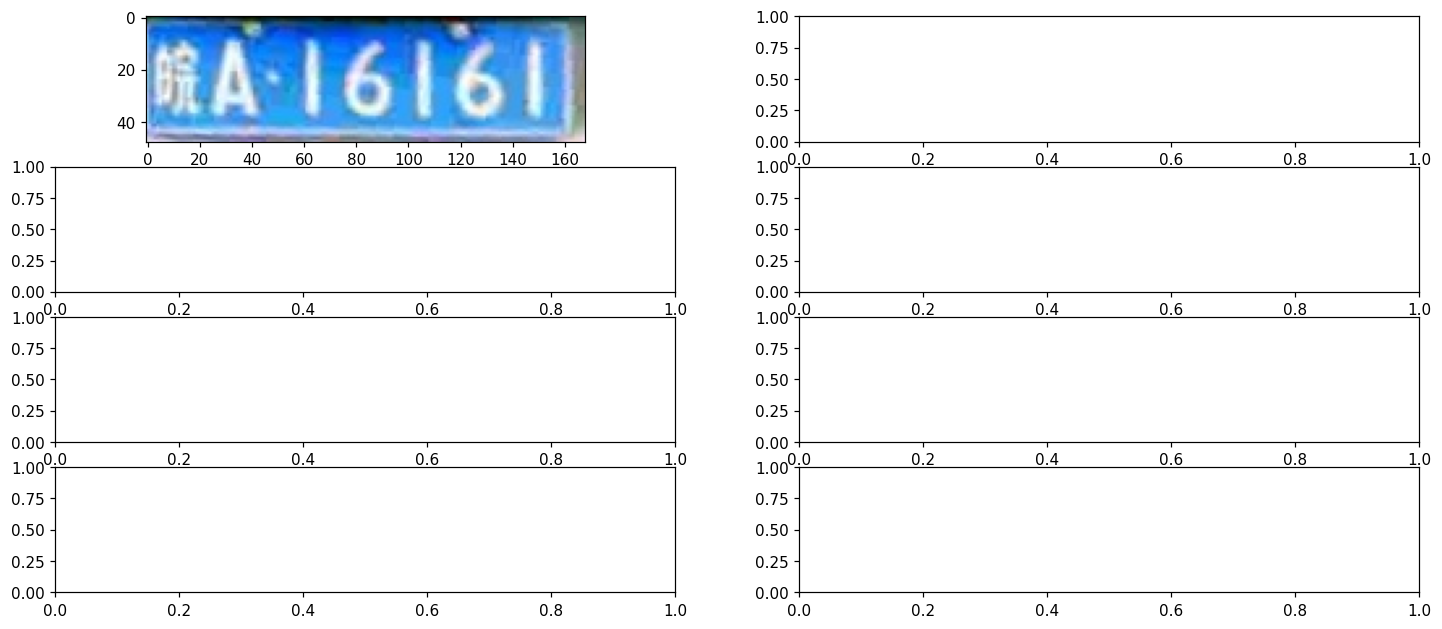

In [21]:
sample = test_df.sample(min(8, len(test_df)), random_state=0).reset_index(drop=True)
test_df_reset = test_df.reset_index(drop=True)
path_to_pos = {p: i for i, p in enumerate(test_df_reset["path"])}
sample["test_pos"] = sample["path"].map(path_to_pos)

def get_pred(i, preds_list):
    if preds_list is None or i is None or i >= len(preds_list): return "—"
    return preds_list[i][1]

cols, rows_n = 2, math.ceil(len(sample)/2)
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*8, rows_n*1.7))
axes = np.array(axes).reshape(-1)
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(r["path"])
    if img is None: ax.axis("off"); continue
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    pos = int(r["test_pos"]) if not pd.isna(r["test_pos"]) else None
    title = (f"truth: {r['plate']}  [{r['subset']}]\n"
             f"LPRNet:  {get_pred(pos, lprnet_test_preds)}\n"
             f"7-head:  {get_pred(pos, head7_test_preds)}\n"
             f"Paddle:  {get_pred(pos, paddle_test_preds)}")
    ax.set_title(title, fontsize=8); ax.axis("off")
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 11. Save artefacts & notes

CSVs are saved into `recognition_results/`. Checkpoints:
- `recognition_results/lprnet_final.pt`
- `recognition_results/head7_final.pt`

**For the paper:** the headline comparison is `headline_comparison.csv`; per-position and per-subset breakdowns are in the same folder. All numbers come from the same frozen test set, so they're directly comparable.

**Honest caveats**
- LPRNet's CV mean ± std (section 6.2) is the *model-selection* number; the frozen-test number is the *headline*. Report both.
- The 7-head CNN uses a single train/val split rather than full CV — the architecture is small and stable enough that CV adds noise rather than signal. Note this if a reviewer asks.
- PaddleOCR's accuracy depends on the model variant — we used `PP-OCRv5_server_rec`; `PP-OCRv5_mobile_rec` would give slightly lower numbers for the speed-accuracy trade-off.